# Data Science and Analytics, DevelopersHub Cororation, Internship Task-5
# Global SuperStore, Business Intelligence Analysis

**Objective:** Analyze sales, profit, and segment performance using the Global SuperStore dataset.  
**Dataset:** 51,290 orders across multiple regions, categories, and customer segments.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Load Dataset

In [2]:
df = pd.read_csv('SuperStore.csv', encoding='latin1')
df.columns = df.columns.str.replace('.', '_', regex=False)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (51290, 27)


,Category,City,Country,Customer_ID,Customer_Name,Discount,Market,è®°å½æ°,Order_Date,Order_ID,...,Sales,Segment,Ship_Date,Ship_Mode,Shipping_Cost,State,Sub_Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32


## 3. Data Cleaning & Preprocessing

In [3]:
# Parse dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'],  dayfirst=True, errors='coerce')

# Drop rows missing key numeric fields
before = len(df)
df.dropna(subset=['Sales', 'Profit'], inplace=True)
print(f'Dropped {before - len(df)} rows with null Sales/Profit')

# Derived columns
df['Year']          = df['Order_Date'].dt.year
df['Month']         = df['Order_Date'].dt.to_period('M').astype(str)
df['Profit_Margin'] = df['Profit'] / df['Sales'].replace(0, np.nan)

print(f'Final shape: {df.shape}')
df[['Sales','Profit','Discount','Quantity','Profit_Margin']].describe().round(2)

Dropped 0 rows with null Sales/Profit
Final shape: (51290, 29)


,Sales,Profit,Discount,Quantity,Profit_Margin
count,51290.00,51290.00,51290.00,51290.00,51289.00
mean,246.50,28.61,0.14,3.48,0.05
std,487.57,174.34,0.21,2.28,0.47
min,0.00,-6599.98,0.00,1.00,-4.73
25%,31.00,0.00,0.00,2.00,0.00
50%,85.00,9.24,0.00,3.00,0.17
75%,251.00,36.81,0.20,5.00,0.33
max,22638.00,8399.98,0.85,14.00,0.58


## 4. KPI Summary

In [4]:
kpis = {
    'Total Sales':    f"${df['Sales'].sum():,.0f}",
    'Total Profit':   f"${df['Profit'].sum():,.0f}",
    'Profit Margin':  f"{df['Profit'].sum()/df['Sales'].sum()*100:.1f}%",
    'Total Orders':   f"{df['Order_ID'].nunique():,}",
    'Unique Customers': f"{df['Customer_Name'].nunique():,}",
    'Countries':      f"{df['Country'].nunique()}",
}
for k, v in kpis.items():
    print(f'{k:22s}: {v}')

Total Sales           : $12,642,905
Total Profit          : $1,467,457
Profit Margin         : 11.6%
Total Orders          : 25,035
Unique Customers      : 795
Countries             : 147


## 5. Exploratory Data Analysis (EDA)

### 5.1 Sales & Profit Trend

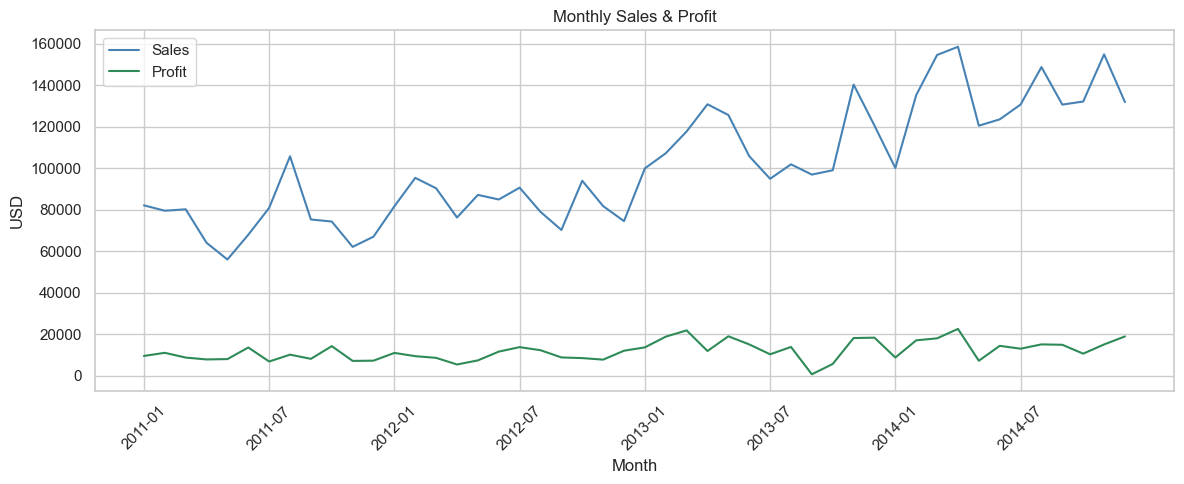

In [5]:
monthly = df.groupby('Month').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()

fig, ax = plt.subplots()
ax.plot(monthly['Month'], monthly['Sales'],  label='Sales',  color='steelblue')
ax.plot(monthly['Month'], monthly['Profit'], label='Profit', color='seagreen')
ax.set_title('Monthly Sales & Profit')
ax.set_xlabel('Month'); ax.set_ylabel('USD')
ax.legend()
plt.xticks(monthly['Month'][::6], rotation=45)
plt.tight_layout(); plt.show()

### 5.2 Sales by Category & Segment

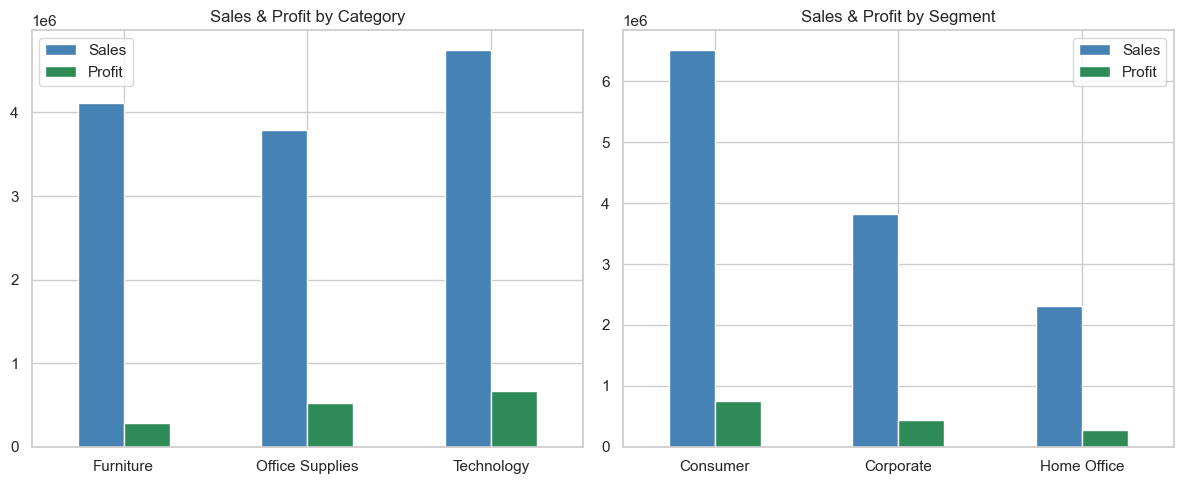

In [6]:
fig, axes = plt.subplots(1, 2)

# Category
cat = df.groupby('Category')[['Sales','Profit']].sum()
cat.plot(kind='bar', ax=axes[0], color=['steelblue','seagreen'], rot=0)
axes[0].set_title('Sales & Profit by Category'); axes[0].set_xlabel('')

# Segment
seg = df.groupby('Segment')[['Sales','Profit']].sum()
seg.plot(kind='bar', ax=axes[1], color=['steelblue','seagreen'], rot=0)
axes[1].set_title('Sales & Profit by Segment'); axes[1].set_xlabel('')

plt.tight_layout(); plt.show()

### 5.3 Top 5 Customers by Sales

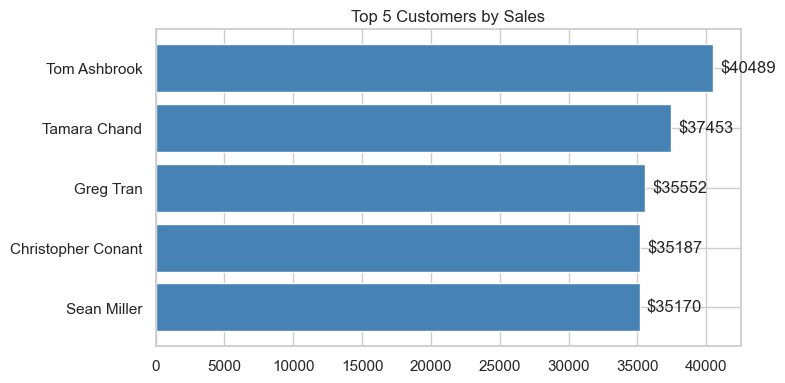

In [7]:
top5 = df.groupby('Customer_Name')['Sales'].sum().nlargest(5).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top5['Customer_Name'], top5['Sales'], color='steelblue')
ax.bar_label(bars, fmt='$%.0f', padding=5)
ax.set_title('Top 5 Customers by Sales')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

### 5.4 Sub-Category Profitability

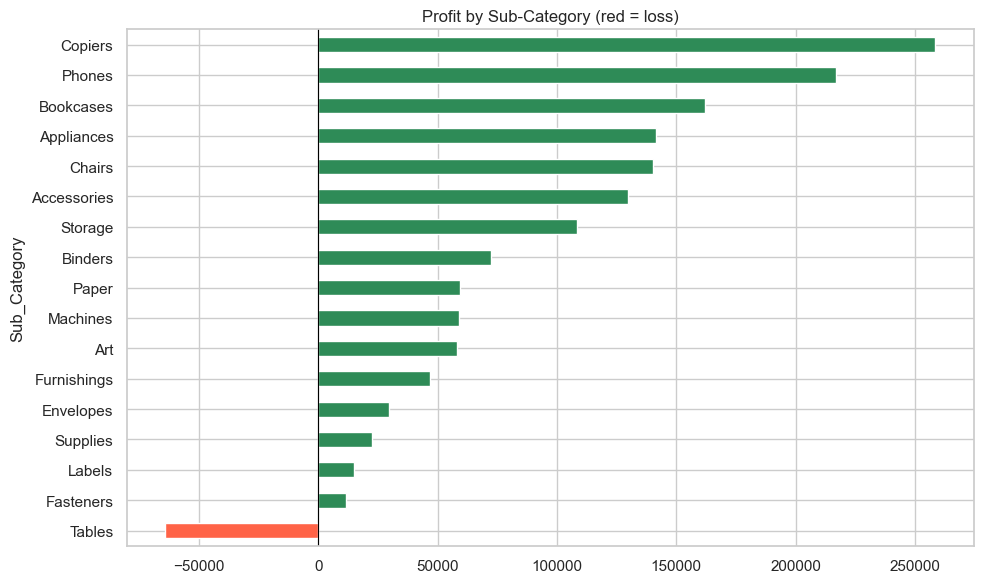

In [8]:
sub = df.groupby('Sub_Category')[['Sales','Profit']].sum().sort_values('Profit')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if p < 0 else 'seagreen' for p in sub['Profit']]
sub['Profit'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Profit by Sub-Category (red = loss)')
plt.tight_layout(); plt.show()

### 5.5 Discount vs Profit

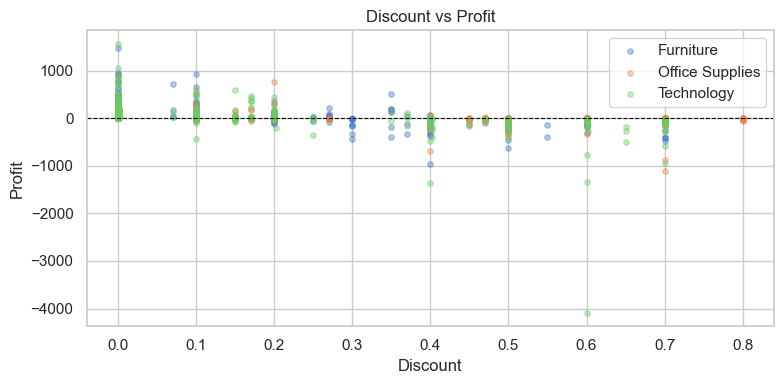

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sample = df.sample(2000, random_state=42)
for cat, grp in sample.groupby('Category'):
    ax.scatter(grp['Discount'], grp['Profit'], label=cat, alpha=0.4, s=15)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Discount vs Profit')
ax.set_xlabel('Discount'); ax.set_ylabel('Profit')
ax.legend()
plt.tight_layout(); plt.show()

### 5.6 Profit Heatmap: Region × Category

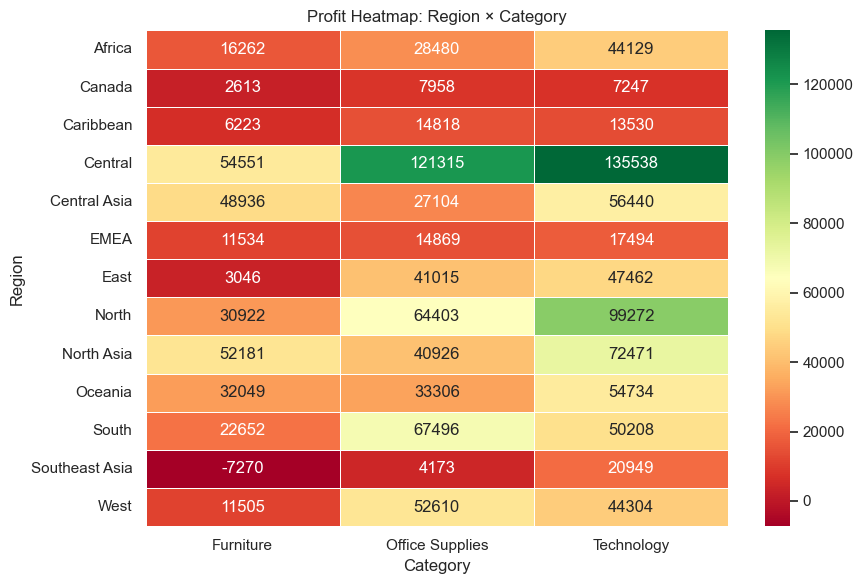

In [10]:
pivot = df.pivot_table(values='Profit', index='Region', columns='Category', aggfunc='sum')

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax, linewidths=0.5)
ax.set_title('Profit Heatmap: Region × Category')
plt.tight_layout(); plt.show()

## 6. Final Conclusions & Insights

### Key Findings

1. **Technology** drives the highest sales but **Office Supplies** has the best profit margin.
2. **Tables** and **Bookcases** sub-categories are loss-makers — review pricing or costs.
3. **Discounts above 20%** consistently destroy profit across all categories.
4. **Consumer segment** generates the most revenue; **Home Office** the least.
5. Top 5 customers (e.g. Tom Ashbrook, Tamara Chand) account for a significant portion of sales — retention is critical.
6. Sales show **year-end seasonality** peaks (Q4 spikes every year).

### Recommendations
- **Cap discounts at 15–20%** to protect margins.
- **Investigate Tables/Bookcases** for repricing or discontinuation.
- **Focus marketing on Consumer segment** and high-value customers.
- **Leverage Q4 seasonality** with targeted promotions.